In [1]:
import os
import getpass
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_DIR = r"C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM"

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data"
)

PROCESSED_DATA_DIR = os.path.join(
    DATA_DIR,
    "processed"
)

SALES_ANALYTICS_DIR = os.path.join(
    PROCESSED_DATA_DIR,
    "sales_analytics"
)

os.makedirs(
    SALES_ANALYTICS_DIR,
    exist_ok=True
)

DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "ecommerce_ai_db"

DB_USER = input(
    "Enter your PostgreSQL username: "
)

DB_PASSWORD = getpass.getpass(
    "Enter your PostgreSQL password: "
)

print("Project configuration loaded successfully.")
print(f"Project directory: {PROJECT_DIR}")
print(f"Database: {DB_NAME}")
print(f"Sales analytics directory: {SALES_ANALYTICS_DIR}")

Enter your PostgreSQL username:  postgres
Enter your PostgreSQL password:  ········


Project configuration loaded successfully.
Project directory: C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM
Database: ecommerce_ai_db
Sales analytics directory: C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed\sales_analytics


In [3]:
DATABASE_URL = (
    "postgresql+psycopg2://"
    f"{DB_USER}:{DB_PASSWORD}@"
    f"{DB_HOST}:{DB_PORT}/"
    f"{DB_NAME}"
)

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True
)

print("PostgreSQL SQLAlchemy engine created successfully.")

PostgreSQL SQLAlchemy engine created successfully.


In [4]:
try:

    with engine.connect() as connection:

        connection.execute(
            text("SELECT 1;")
        )

    print(
        "PostgreSQL connection successful."
    )

except SQLAlchemyError as error:

    print(
        "PostgreSQL connection failed."
    )

    print(
        "Check your username, password, host, port, and database name."
    )

    raise error

PostgreSQL connection successful.


In [5]:
database_info_query = """
SELECT
    current_database() AS database_name,
    current_user AS current_user,
    current_schema() AS current_schema,
    version() AS postgresql_version;
"""

database_info = pd.read_sql(
    text(database_info_query),
    engine
)

database_info

,database_name,current_user,current_schema,postgresql_version
0,ecommerce_ai_db,postgres,public,"PostgreSQL 18.4 on x86_64-windows, compiled by..."


In [6]:
schemas_query = """
SELECT
    schema_name
FROM information_schema.schemata
WHERE schema_name NOT IN (
    'pg_catalog',
    'information_schema'
)
ORDER BY schema_name;
"""

schemas_df = pd.read_sql(
    text(schemas_query),
    engine
)

schemas_df

,schema_name
0,feature_engineered
1,pg_toast
2,public
3,sales_analytics


In [7]:
tables_query = """
SELECT
    table_schema,
    table_name,
    table_type
FROM information_schema.tables
WHERE table_schema NOT IN (
    'pg_catalog',
    'information_schema'
)
ORDER BY
    table_schema,
    table_name;
"""

all_tables_df = pd.read_sql(
    text(tables_query),
    engine
)

all_tables_df

,table_schema,table_name,table_type
0,feature_engineered,category_features,BASE TABLE
1,feature_engineered,customer_features,BASE TABLE
2,feature_engineered,monthly_sales_features,BASE TABLE
3,feature_engineered,order_features,BASE TABLE
4,feature_engineered,product_features,BASE TABLE
5,feature_engineered,seller_features,BASE TABLE
6,public,category_translation,BASE TABLE
7,public,customers,BASE TABLE
8,public,geolocation,BASE TABLE
9,public,order_items,BASE TABLE


In [8]:
feature_engineered_tables_query = """
SELECT
    table_schema,
    table_name,
    table_type
FROM information_schema.tables
WHERE table_schema = 'feature_engineered'
ORDER BY table_name;
"""

feature_engineered_tables = pd.read_sql(
    text(feature_engineered_tables_query),
    engine
)

if feature_engineered_tables.empty:

    raise RuntimeError(
        "The feature_engineered schema does not contain any tables. "
        "Run 07_feature_engineering.ipynb successfully before continuing."
    )

feature_engineered_tables

,table_schema,table_name,table_type
0,feature_engineered,category_features,BASE TABLE
1,feature_engineered,customer_features,BASE TABLE
2,feature_engineered,monthly_sales_features,BASE TABLE
3,feature_engineered,order_features,BASE TABLE
4,feature_engineered,product_features,BASE TABLE
5,feature_engineered,seller_features,BASE TABLE


In [9]:
feature_tables = (
    feature_engineered_tables[
        "table_name"
    ]
    .tolist()
)

print("Verified feature_engineered tables:")

for table_name in feature_tables:

    print(
        f"✓ feature_engineered.{table_name}"
    )

Verified feature_engineered tables:
✓ feature_engineered.category_features
✓ feature_engineered.customer_features
✓ feature_engineered.monthly_sales_features
✓ feature_engineered.order_features
✓ feature_engineered.product_features
✓ feature_engineered.seller_features


In [10]:
columns_query = """
SELECT
    table_schema,
    table_name,
    ordinal_position,
    column_name,
    data_type,
    udt_name,
    is_nullable
FROM information_schema.columns
WHERE table_schema = 'feature_engineered'
ORDER BY
    table_name,
    ordinal_position;
"""

feature_columns = pd.read_sql(
    text(columns_query),
    engine
)

feature_columns

,table_schema,table_name,ordinal_position,column_name,data_type,udt_name,is_nullable
0,feature_engineered,category_features,1,product_category_name,text,text,YES
1,feature_engineered,category_features,2,unique_products,bigint,int8,YES
2,feature_engineered,category_features,3,total_units_sold,bigint,int8,YES
3,feature_engineered,category_features,4,total_revenue,double precision,float8,YES
4,feature_engineered,category_features,5,average_product_price,double precision,float8,YES
...,...,...,...,...,...,...,...
99,feature_engineered,seller_features,6,total_revenue,double precision,float8,YES
100,feature_engineered,seller_features,7,average_item_price,double precision,float8,YES
101,feature_engineered,seller_features,8,total_freight_value,double precision,float8,YES
102,feature_engineered,seller_features,9,unique_products_sold,bigint,int8,YES


In [11]:
for table_name in feature_tables:

    print(
        "\n" + "=" * 100
    )

    print(
        f"TABLE: feature_engineered.{table_name}"
    )

    print(
        "=" * 100
    )

    display(
        feature_columns[
            feature_columns["table_name"] == table_name
        ][
            [
                "ordinal_position",
                "column_name",
                "data_type",
                "udt_name",
                "is_nullable"
            ]
        ]
    )


TABLE: feature_engineered.category_features


,ordinal_position,column_name,data_type,udt_name,is_nullable
0,1,product_category_name,text,text,YES
1,2,unique_products,bigint,int8,YES
2,3,total_units_sold,bigint,int8,YES
3,4,total_revenue,double precision,float8,YES
4,5,average_product_price,double precision,float8,YES



TABLE: feature_engineered.customer_features


,ordinal_position,column_name,data_type,udt_name,is_nullable
5,1,customer_id,text,text,YES
6,2,customer_unique_id,text,text,YES
7,3,customer_zip_code_prefix,bigint,int8,YES
8,4,customer_city,text,text,YES
9,5,customer_state,text,text,YES
10,6,total_orders,bigint,int8,YES
11,7,total_spend,double precision,float8,YES
12,8,average_order_value,double precision,float8,YES
13,9,total_items_purchased,double precision,float8,YES
14,10,average_review_score,double precision,float8,YES



TABLE: feature_engineered.monthly_sales_features


...

,ordinal_position,column_name,data_type,udt_name,is_nullable
41,1,order_id,text,text,YES
42,2,customer_id,text,text,YES
43,3,order_status,text,text,YES
44,4,order_purchase_timestamp,timestamp without time zone,timestamp,YES
45,5,order_approved_at,timestamp without time zone,timestamp,YES
46,6,order_delivered_carrier_date,timestamp without time zone,timestamp,YES
47,7,order_delivered_customer_date,timestamp without time zone,timestamp,YES
48,8,order_estimated_delivery_date,timestamp without time zone,timestamp,YES
49,9,delivery_days,double precision,float8,YES
50,10,estimated_delivery_days,double precision,float8,YES



TABLE: feature_engineered.product_features


,ordinal_position,column_name,data_type,udt_name,is_nullable
76,1,product_id,text,text,YES
77,2,product_category_name,text,text,YES
78,3,product_name_lenght,double precision,float8,YES
79,4,product_description_lenght,double precision,float8,YES
80,5,product_photos_qty,double precision,float8,YES
81,6,product_weight_g,double precision,float8,YES
82,7,product_length_cm,double precision,float8,YES
83,8,product_height_cm,double precision,float8,YES
84,9,product_width_cm,double precision,float8,YES
85,10,product_category_name_english,text,text,YES



TABLE: feature_engineered.seller_features


,ordinal_position,column_name,data_type,udt_name,is_nullable
94,1,seller_id,text,text,YES
95,2,seller_zip_code_prefix,bigint,int8,YES
96,3,seller_city,text,text,YES
97,4,seller_state,text,text,YES
98,5,total_items_sold,bigint,int8,YES
99,6,total_revenue,double precision,float8,YES
100,7,average_item_price,double precision,float8,YES
101,8,total_freight_value,double precision,float8,YES
102,9,unique_products_sold,bigint,int8,YES
103,10,unique_orders,bigint,int8,YES


In [12]:
row_count_results = []

for table_name in feature_tables:

    safe_table_name = (
        table_name
        .replace('"', '""')
    )

    count_query = text(
        f'''
        SELECT
            COUNT(*) AS row_count
        FROM
            "feature_engineered"."{safe_table_name}";
        '''
    )

    with engine.connect() as connection:

        row_count = connection.execute(
            count_query
        ).scalar()

    row_count_results.append(
        {
            "table_name": table_name,
            "row_count": row_count
        }
    )

row_counts = pd.DataFrame(
    row_count_results
)

row_counts

,table_name,row_count
0,category_features,74
1,customer_features,99441
2,monthly_sales_features,25
3,order_features,99441
4,product_features,32951
5,seller_features,3095


In [13]:
column_map = {}

for table_name in feature_tables:

    table_columns = (
        feature_columns[
            feature_columns["table_name"] == table_name
        ]
        ["column_name"]
        .tolist()
    )

    column_map[
        table_name
    ] = table_columns

column_map

{'category_features': ['product_category_name',
  'unique_products',
  'total_units_sold',
  'total_revenue',
  'average_product_price'],
 'customer_features': ['customer_id',
  'customer_unique_id',
  'customer_zip_code_prefix',
  'customer_city',
  'customer_state',
  'total_orders',
  'total_spend',
  'average_order_value',
  'total_items_purchased',
  'average_review_score',
  'average_delivery_days',
  'average_delivery_delay_days',
  'late_orders',
  'cancelled_orders',
  'first_purchase_date',
  'last_purchase_date',
  'customer_lifetime_days',
  'purchase_frequency',
  'recency_days',
  'frequency',
  'monetary',
  'recency_score',
  'frequency_score',
  'monetary_score',
  'rfm_score'],
 'monthly_sales_features': ['purchase_month_start',
  'total_orders',
  'total_revenue',
  'total_items_sold',
  'average_order_value',
  'average_delivery_days',
  'average_review_score',
  'late_orders',
  'cancelled_orders',
  'revenue_growth',
  'order_growth'],
 'order_features': ['order_i

In [14]:
for table_name, columns in column_map.items():

    print(
        f"\n{table_name}"
    )

    for column in columns:

        print(
            f"  - {column}"
        )


category_features
  - product_category_name
  - unique_products
  - total_units_sold
  - total_revenue
  - average_product_price

customer_features
  - customer_id
  - customer_unique_id
  - customer_zip_code_prefix
  - customer_city
  - customer_state
  - total_orders
  - total_spend
  - average_order_value
  - total_items_purchased
  - average_review_score
  - average_delivery_days
  - average_delivery_delay_days
  - late_orders
  - cancelled_orders
  - first_purchase_date
  - last_purchase_date
  - customer_lifetime_days
  - purchase_frequency
  - recency_days
  - frequency
  - monetary
  - recency_score
  - frequency_score
  - monetary_score
  - rfm_score

monthly_sales_features
  - purchase_month_start
  - total_orders
  - total_revenue
  - total_items_sold
  - average_order_value
  - average_delivery_days
  - average_review_score
  - late_orders
  - cancelled_orders
  - revenue_growth
  - order_growth

order_features
  - order_id
  - customer_id
  - order_status
  - order_purcha

In [15]:
candidate_columns = [
    "order_id",
    "customer_id",
    "seller_id",
    "product_id",
    "order_status",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "price",
    "freight_value",
    "payment_value",
    "review_score",
    "total_items",
    "total_product_value",
    "total_freight_value",
    "total_order_value",
    "delivery_days",
    "is_late",
    "order_year",
    "order_month",
    "order_quarter",
    "order_day_of_week",
    "order_date",
    "year_month"
]

column_availability = []

for table_name in feature_tables:

    existing_columns = (
        set(
            column_map[
                table_name
            ]
        )
    )

    for column_name in candidate_columns:

        column_availability.append(
            {
                "table_name": table_name,
                "column_name": column_name,
                "exists": column_name in existing_columns
            }
        )

column_availability_df = pd.DataFrame(
    column_availability
)

column_availability_df[
    column_availability_df["exists"] == True
]

,table_name,column_name,exists
27,customer_features,customer_id,True
78,order_features,order_id,True
79,order_features,customer_id,True
82,order_features,order_status,True
83,order_features,order_purchase_timestamp,True
84,order_features,order_approved_at,True
85,order_features,order_delivered_carrier_date,True
86,order_features,order_delivered_customer_date,True
87,order_features,order_estimated_delivery_date,True
91,order_features,review_score,True


In [16]:
order_table_candidates = [
    table_name
    for table_name in feature_tables
    if "order_id"
    in column_map[table_name]
]

if not order_table_candidates:

    raise RuntimeError(
        "No feature_engineered table contains order_id. "
        "Sales analytics cannot be generated safely without a verified order-level key."
    )

print(
    "Tables containing order_id:"
)

for table_name in order_table_candidates:

    print(
        f"✓ {table_name}"
    )

Tables containing order_id:
✓ order_features


In [17]:
def choose_best_order_table(
    table_names,
    column_map
):

    preferred_columns = [
        "total_order_value",
        "total_product_value",
        "total_freight_value",
        "order_status",
        "delivery_days",
        "is_late"
    ]

    scores = []

    for table_name in table_names:

        columns = set(
            column_map[
                table_name
            ]
        )

        score = sum(
            column in columns
            for column in preferred_columns
        )

        scores.append(
            {
                "table_name": table_name,
                "score": score
            }
        )

    score_df = pd.DataFrame(
        scores
    )

    score_df = score_df.sort_values(
        by=[
            "score",
            "table_name"
        ],
        ascending=[
            False,
            True
        ]
    )

    return score_df.iloc[0]["table_name"]


order_table = choose_best_order_table(
    order_table_candidates,
    column_map
)

print(
    f"Selected verified order-level table: feature_engineered.{order_table}"
)

Selected verified order-level table: feature_engineered.order_features


In [18]:
order_columns = set(
    column_map[
        order_table
    ]
)

print(
    "Verified columns in selected order-level table:"
)

for column_name in sorted(
    order_columns
):

    print(
        f"✓ {column_name}"
    )

Verified columns in selected order-level table:
✓ customer_id
✓ delivery_days
✓ delivery_delay_days
✓ delivery_status
✓ estimated_delivery_days
✓ is_cancelled
✓ is_delivered
✓ is_late
✓ is_on_time
✓ max_payment_installments
✓ order_approved_at
✓ order_delivered_carrier_date
✓ order_delivered_customer_date
✓ order_estimated_delivery_date
✓ order_id
✓ order_month
✓ order_purchase_timestamp
✓ order_quarter
✓ order_status
✓ order_weekday
✓ order_year
✓ payment_methods_used
✓ purchase_date
✓ purchase_day_of_week
✓ purchase_hour
✓ purchase_month
✓ purchase_month_start
✓ purchase_quarter
✓ purchase_year
✓ review_score
✓ total_freight_value
✓ total_items
✓ total_order_value
✓ total_payment_value
✓ total_product_value


In [19]:
def quote_identifier(
    identifier
):

    return (
        '"'
        + identifier.replace(
            '"',
            '""'
        )
        + '"'
    )


def qualified_table_name(
    schema_name,
    table_name
):

    return (
        quote_identifier(
            schema_name
        )
        + "."
        + quote_identifier(
            table_name
        )
    )


def numeric_expression(
    column_name
):

    return (
        f"NULLIF("
        f"CAST("
        f"{quote_identifier(column_name)} "
        f"AS text"
        f"), "
        f"''"
        f")::numeric"
    )


def text_expression(
    column_name
):

    return (
        f"CAST("
        f"{quote_identifier(column_name)} "
        f"AS text"
        f")"
    )

In [20]:
verified_order_table = qualified_table_name(
    "feature_engineered",
    order_table
)

print(
    verified_order_table
)

"feature_engineered"."order_features"


In [21]:
analytics_expressions = []

analytics_expressions.append(
    "COUNT(*)::bigint AS total_orders"
)

if "order_status" in order_columns:

    analytics_expressions.extend(
        [
            """
            COUNT(*) FILTER (
                WHERE LOWER(
                    CAST("order_status" AS text)
                ) = 'delivered'
            )::bigint AS delivered_orders
            """,

            """
            COUNT(*) FILTER (
                WHERE LOWER(
                    CAST("order_status" AS text)
                ) IN ('canceled', 'cancelled')
            )::bigint AS cancelled_orders
            """
        ]
    )

if "total_items" in order_columns:

    analytics_expressions.extend(
        [
            f"""
            COALESCE(
                SUM(
                    {numeric_expression("total_items")}
                ),
                0
            ) AS total_items
            """,

            f"""
            AVG(
                {numeric_expression("total_items")}
            ) AS average_items_per_order
            """
        ]
    )

if "total_product_value" in order_columns:

    analytics_expressions.append(
        f"""
        COALESCE(
            SUM(
                {numeric_expression("total_product_value")}
            ),
            0
        ) AS total_product_value
        """
    )

if "total_freight_value" in order_columns:

    analytics_expressions.extend(
        [
            f"""
            COALESCE(
                SUM(
                    {numeric_expression("total_freight_value")}
                ),
                0
            ) AS total_freight_value
            """,

            f"""
            AVG(
                {numeric_expression("total_freight_value")}
            ) AS average_freight_per_order
            """
        ]
    )

if "total_order_value" in order_columns:

    analytics_expressions.extend(
        [
            f"""
            COALESCE(
                SUM(
                    {numeric_expression("total_order_value")}
                ),
                0
            ) AS total_order_value
            """,

            f"""
            AVG(
                {numeric_expression("total_order_value")}
            ) AS average_order_value
            """
        ]
    )

if "delivery_days" in order_columns:

    analytics_expressions.append(
        f"""
        AVG(
            {numeric_expression("delivery_days")}
        ) AS average_delivery_days
        """
    )

if "is_late" in order_columns:

    analytics_expressions.append(
        """
        AVG(
            CASE
                WHEN CAST("is_late" AS numeric) = 1
                THEN 1.0
                ELSE 0.0
            END
        ) AS late_delivery_rate
        """
    )

if "review_score" in order_columns:

    analytics_expressions.append(
        f"""
        AVG(
            {numeric_expression("review_score")}
        ) AS average_review_score
        """
    )

overall_sales_sql = f"""
SELECT
    {", ".join(analytics_expressions)}
FROM
    {verified_order_table};
"""

print(
    overall_sales_sql
)


SELECT
    COUNT(*)::bigint AS total_orders, 
            COUNT(*) FILTER (
                WHERE LOWER(
                    CAST("order_status" AS text)
                ) = 'delivered'
            )::bigint AS delivered_orders
            , 
            COUNT(*) FILTER (
                WHERE LOWER(
                    CAST("order_status" AS text)
                ) IN ('canceled', 'cancelled')
            )::bigint AS cancelled_orders
            , 
            COALESCE(
                SUM(
                    NULLIF(CAST("total_items" AS text), '')::numeric
                ),
                0
            ) AS total_items
            , 
            AVG(
                NULLIF(CAST("total_items" AS text), '')::numeric
            ) AS average_items_per_order
            , 
        COALESCE(
            SUM(
                NULLIF(CAST("total_product_value" AS text), '')::numeric
            ),
            0
        ) AS total_product_value
        , 
            COALESCE(
          

In [22]:
create_sales_schema_sql = """
CREATE SCHEMA IF NOT EXISTS sales_analytics;
"""

with engine.begin() as connection:

    connection.execute(
        text(
            create_sales_schema_sql
        )
    )

print(
    "Schema sales_analytics is ready."
)

Schema sales_analytics is ready.


In [23]:
drop_overall_sql = """
DROP TABLE IF EXISTS
    sales_analytics.overall_sales_kpis;
"""

create_overall_sql = f"""
CREATE TABLE
    sales_analytics.overall_sales_kpis
AS
{overall_sales_sql}
"""

with engine.begin() as connection:

    connection.execute(
        text(
            drop_overall_sql
        )
    )

    connection.execute(
        text(
            create_overall_sql
        )
    )

overall_sales_kpis = pd.read_sql(
    text(
        """
        SELECT *
        FROM
            sales_analytics.overall_sales_kpis;
        """
    ),
    engine
)

overall_sales_kpis

,total_orders,delivered_orders,cancelled_orders,total_items,average_items_per_order,total_product_value,total_freight_value,average_freight_per_order,total_order_value,average_order_value,average_delivery_days,late_delivery_rate,average_review_score
0,99441,96478,625,112650.0,1.132833,13591643.7,2251909.54,22.645685,15843553.24,159.326166,12.921854,0.07871,4.05523


In [24]:
date_column_candidates = [
    "order_date",
    "order_purchase_timestamp"
]

date_column = next(
    (
        column
        for column in date_column_candidates
        if column in order_columns
    ),
    None
)

if date_column is None:

    print(
        "No verified order date column exists."
    )

else:

    print(
        f"Verified date column: {date_column}"
    )

Verified date column: order_purchase_timestamp


In [25]:
if date_column is not None:

    monthly_expressions = [
        f"""
        DATE_TRUNC(
            'month',
            CAST(
                "{date_column}"
                AS timestamp
            )
        )::date AS sales_month
        """,
        "COUNT(*)::bigint AS total_orders"
    ]

    if "total_order_value" in order_columns:

        monthly_expressions.append(
            f"""
            COALESCE(
                SUM(
                    {numeric_expression("total_order_value")}
                ),
                0
            ) AS total_order_value
            """
        )

        monthly_expressions.append(
            f"""
            AVG(
                {numeric_expression("total_order_value")}
            ) AS average_order_value
            """
        )

    if "total_product_value" in order_columns:

        monthly_expressions.append(
            f"""
            COALESCE(
                SUM(
                    {numeric_expression("total_product_value")}
                ),
                0
            ) AS total_product_value
            """
        )

    if "total_freight_value" in order_columns:

        monthly_expressions.append(
            f"""
            COALESCE(
                SUM(
                    {numeric_expression("total_freight_value")}
                ),
                0
            ) AS total_freight_value
            """
        )

    monthly_sales_sql = f"""
    SELECT
        {", ".join(monthly_expressions)}
    FROM
        {verified_order_table}
    GROUP BY
        DATE_TRUNC(
            'month',
            CAST(
                "{date_column}"
                AS timestamp
            )
        )::date
    ORDER BY
        sales_month;
    """

    drop_monthly_sql = """
    DROP TABLE IF EXISTS
        sales_analytics.monthly_sales;
    """

    create_monthly_sql = f"""
    CREATE TABLE
        sales_analytics.monthly_sales
    AS
    {monthly_sales_sql}
    """

    with engine.begin() as connection:

        connection.execute(
            text(
                drop_monthly_sql
            )
        )

        connection.execute(
            text(
                create_monthly_sql
            )
        )

    monthly_sales = pd.read_sql(
        text(
            """
            SELECT *
            FROM
                sales_analytics.monthly_sales
            ORDER BY
                sales_month;
            """
        ),
        engine
    )

    monthly_sales.head()

else:

    monthly_sales = pd.DataFrame()

    print(
        "Monthly sales table was skipped because no verified date column exists."
    )

In [26]:
if date_column is not None:

    monthly_sales

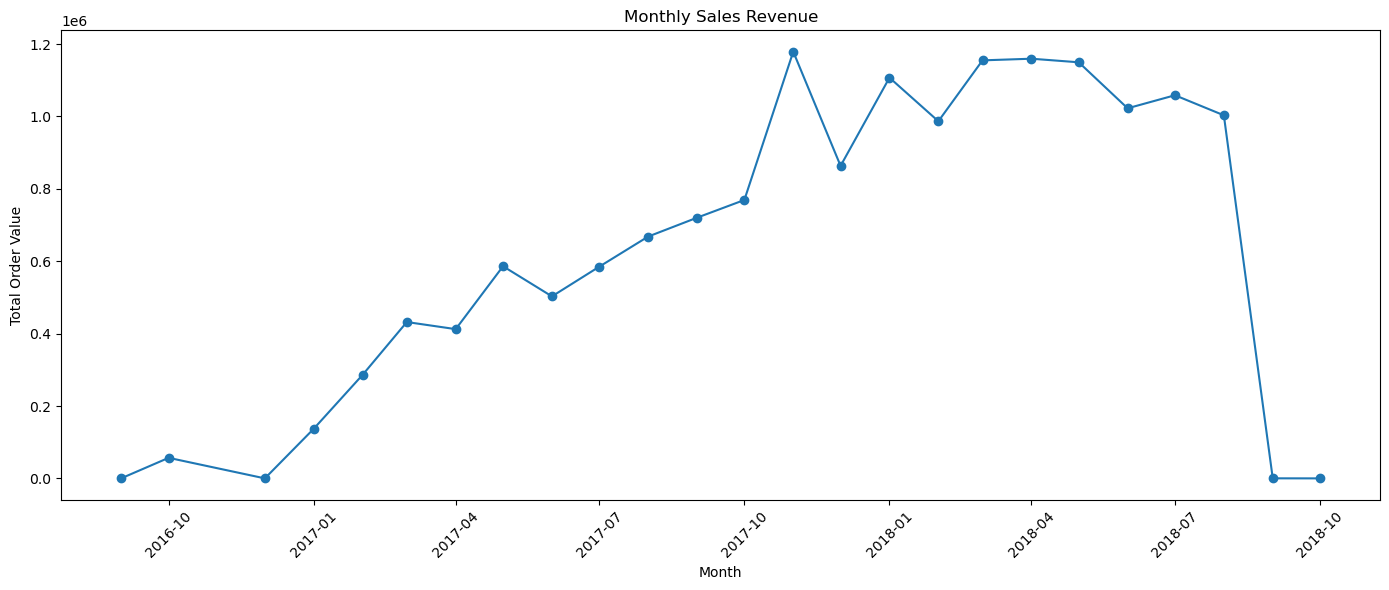

In [27]:
if date_column is not None:

    plt.figure(
        figsize=(
            14,
            6
        )
    )

    if "total_order_value" in monthly_sales.columns:

        plt.plot(
            monthly_sales["sales_month"],
            monthly_sales["total_order_value"],
            marker="o"
        )

        plt.title(
            "Monthly Sales Revenue"
        )

        plt.xlabel(
            "Month"
        )

        plt.ylabel(
            "Total Order Value"
        )

        plt.xticks(
            rotation=45
        )

        plt.tight_layout()

        plt.show()

    else:

        print(
            "Revenue chart skipped because total_order_value was not verified."
        )

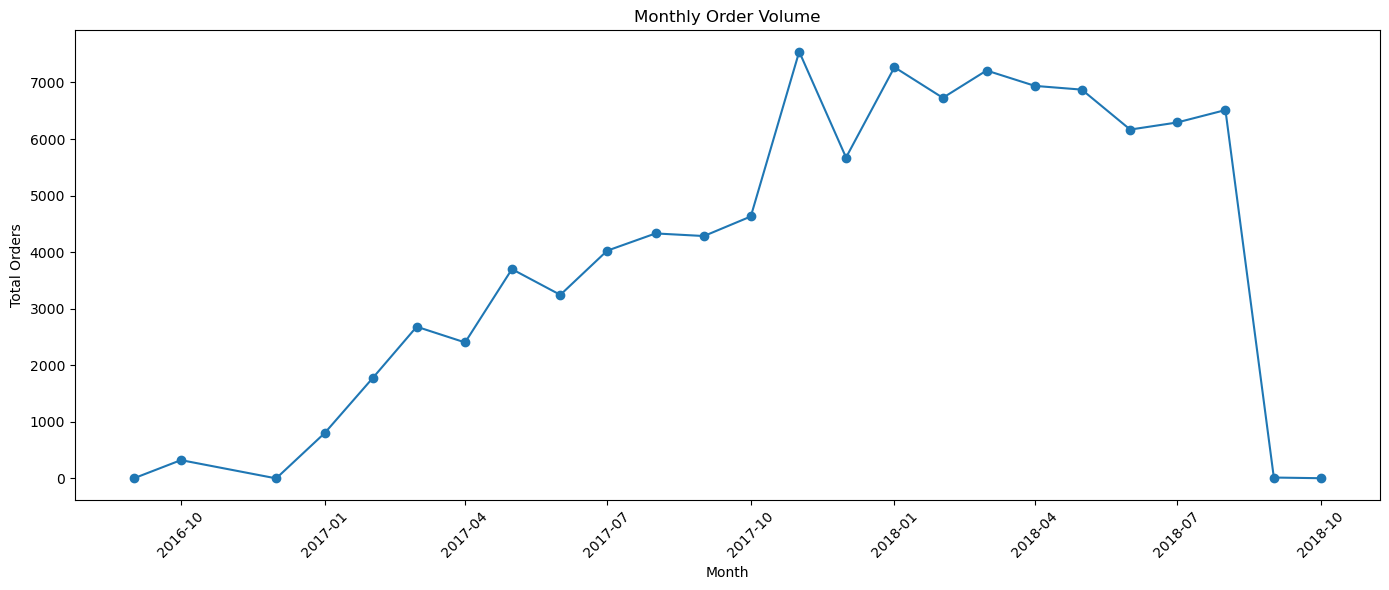

In [28]:
if date_column is not None:

    plt.figure(
        figsize=(
            14,
            6
        )
    )

    plt.plot(
        monthly_sales["sales_month"],
        monthly_sales["total_orders"],
        marker="o"
    )

    plt.title(
        "Monthly Order Volume"
    )

    plt.xlabel(
        "Month"
    )

    plt.ylabel(
        "Total Orders"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.show()

In [29]:
status_column_exists = (
    "order_status"
    in order_columns
)

if status_column_exists:

    status_sql = f"""
    SELECT
        LOWER(
            CAST(
                "order_status"
                AS text
            )
        ) AS order_status,
        COUNT(*)::bigint AS order_count
    FROM
        {verified_order_table}
    GROUP BY
        LOWER(
            CAST(
                "order_status"
                AS text
            )
        )
    ORDER BY
        order_count DESC;
    """

    drop_status_sql = """
    DROP TABLE IF EXISTS
        sales_analytics.order_status_summary;
    """

    create_status_sql = f"""
    CREATE TABLE
        sales_analytics.order_status_summary
    AS
    {status_sql}
    """

    with engine.begin() as connection:

        connection.execute(
            text(
                drop_status_sql
            )
        )

        connection.execute(
            text(
                create_status_sql
            )
        )

    order_status_summary = pd.read_sql(
        text(
            """
            SELECT *
            FROM
                sales_analytics.order_status_summary
            ORDER BY
                order_count DESC;
            """
        ),
        engine
    )

    order_status_summary

else:

    order_status_summary = pd.DataFrame()

    print(
        "Order status analysis skipped because order_status was not verified."
    )

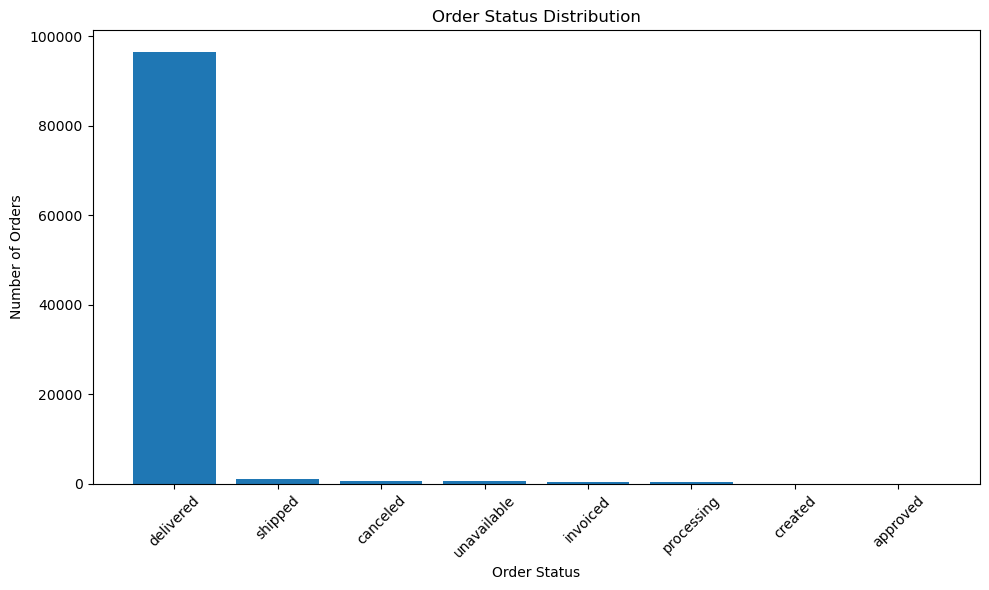

In [30]:
if not order_status_summary.empty:

    plt.figure(
        figsize=(
            10,
            6
        )
    )

    plt.bar(
        order_status_summary["order_status"],
        order_status_summary["order_count"]
    )

    plt.title(
        "Order Status Distribution"
    )

    plt.xlabel(
        "Order Status"
    )

    plt.ylabel(
        "Number of Orders"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.show()

In [31]:
if (
    "is_late" in order_columns
    and "delivery_days" in order_columns
):

    delivery_sql = f"""
    SELECT
        CASE
            WHEN CAST(
                "is_late"
                AS numeric
            ) = 1
            THEN 'Late'
            ELSE 'On Time'
        END AS delivery_status,

        COUNT(*)::bigint AS order_count,

        AVG(
            {numeric_expression("delivery_days")}
        ) AS average_delivery_days

    FROM
        {verified_order_table}

    GROUP BY
        CASE
            WHEN CAST(
                "is_late"
                AS numeric
            ) = 1
            THEN 'Late'
            ELSE 'On Time'
        END

    ORDER BY
        order_count DESC;
    """

    drop_delivery_sql = """
    DROP TABLE IF EXISTS
        sales_analytics.delivery_performance;
    """

    create_delivery_sql = f"""
    CREATE TABLE
        sales_analytics.delivery_performance
    AS
    {delivery_sql}
    """

    with engine.begin() as connection:

        connection.execute(
            text(
                drop_delivery_sql
            )
        )

        connection.execute(
            text(
                create_delivery_sql
            )
        )

    delivery_performance = pd.read_sql(
        text(
            """
            SELECT *
            FROM
                sales_analytics.delivery_performance;
            """
        ),
        engine
    )

    delivery_performance

else:

    delivery_performance = pd.DataFrame()

    print(
        "Delivery analysis skipped because both is_late and delivery_days were not verified."
    )

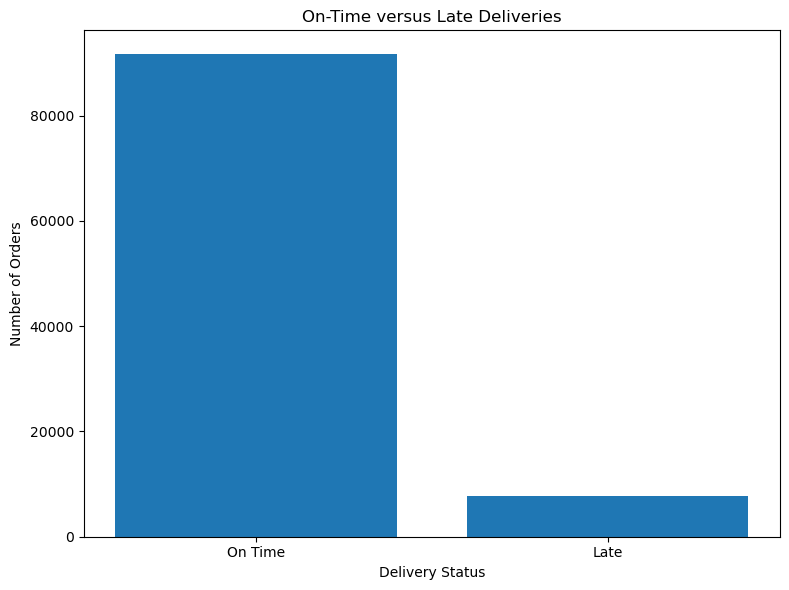

In [32]:
if not delivery_performance.empty:

    plt.figure(
        figsize=(
            8,
            6
        )
    )

    plt.bar(
        delivery_performance["delivery_status"],
        delivery_performance["order_count"]
    )

    plt.title(
        "On-Time versus Late Deliveries"
    )

    plt.xlabel(
        "Delivery Status"
    )

    plt.ylabel(
        "Number of Orders"
    )

    plt.tight_layout()

    plt.show()

In [33]:
export_tables = [
    "overall_sales_kpis",
    "monthly_sales",
    "order_status_summary",
    "delivery_performance"
]

exported_files = []

for table_name in export_tables:

    table_exists_query = """
    SELECT EXISTS (
        SELECT 1
        FROM information_schema.tables
        WHERE table_schema = 'sales_analytics'
        AND table_name = :table_name
    );
    """

    table_exists = pd.read_sql(
        text(
            table_exists_query
        ),
        engine,
        params={
            "table_name": table_name
        }
    ).iloc[0, 0]

    if table_exists:

        export_query = f"""
        SELECT *
        FROM
            sales_analytics."{table_name}";
        """

        export_df = pd.read_sql(
            text(
                export_query
            ),
            engine
        )

        output_path = os.path.join(
            SALES_ANALYTICS_DIR,
            f"{table_name}.csv"
        )

        export_df.to_csv(
            output_path,
            index=False
        )

        exported_files.append(
            {
                "table_name": table_name,
                "file_path": output_path,
                "rows": len(export_df),
                "columns": len(export_df.columns)
            }
        )

export_summary = pd.DataFrame(
    exported_files
)

export_summary

,table_name,file_path,rows,columns
0,overall_sales_kpis,C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\...,1,13
1,monthly_sales,C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\...,25,6
2,order_status_summary,C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\...,8,2
3,delivery_performance,C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\...,2,3


In [34]:
final_tables_query = """
SELECT
    table_schema,
    table_name
FROM information_schema.tables
WHERE table_schema = 'sales_analytics'
ORDER BY table_name;
"""

final_tables = pd.read_sql(
    text(
        final_tables_query
    ),
    engine
)

final_tables

,table_schema,table_name
0,sales_analytics,delivery_performance
1,sales_analytics,monthly_sales
2,sales_analytics,order_status_summary
3,sales_analytics,overall_sales_kpis


In [35]:
final_columns_query = """
SELECT
    table_schema,
    table_name,
    ordinal_position,
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = 'sales_analytics'
ORDER BY
    table_name,
    ordinal_position;
"""

final_columns = pd.read_sql(
    text(
        final_columns_query
    ),
    engine
)

final_columns

,table_schema,table_name,ordinal_position,column_name,data_type
0,sales_analytics,delivery_performance,1,delivery_status,text
1,sales_analytics,delivery_performance,2,order_count,bigint
2,sales_analytics,delivery_performance,3,average_delivery_days,numeric
3,sales_analytics,monthly_sales,1,sales_month,date
4,sales_analytics,monthly_sales,2,total_orders,bigint
5,sales_analytics,monthly_sales,3,total_order_value,numeric
6,sales_analytics,monthly_sales,4,average_order_value,numeric
7,sales_analytics,monthly_sales,5,total_product_value,numeric
8,sales_analytics,monthly_sales,6,total_freight_value,numeric
9,sales_analytics,order_status_summary,1,order_status,text


In [38]:
print(
    "08_sales_analytics.ipynb completed successfully."
)

print(
    f"PostgreSQL database: {DB_NAME}"
)

print(
    "Schema created/updated: sales_analytics"
)

print(
    f"Export directory: {SALES_ANALYTICS_DIR}"
)



08_sales_analytics.ipynb completed successfully.
PostgreSQL database: ecommerce_ai_db
Schema created/updated: sales_analytics
Export directory: C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed\sales_analytics
